In [1]:
import os
from dotenv import load_dotenv

if os.environ.get("OPENAI_API_KEY"):
    print("OPENAI_API_KEY is available")
else:
    raise ValueError("OPENAI_API_KEY is not available")

print()

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = "gpt-5.4-nano",
    temperature = 0.7
)

llm

OPENAI_API_KEY is available



ChatOpenAI(output_version=None, profile={'name': 'GPT-5.4 nano', 'release_date': '2026-03-17', 'last_updated': '2026-03-17', 'open_weights': False, 'max_input_tokens': 400000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001A786399E80>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001A786D1B530>, root_client=<openai.OpenAI object at 0x000001A7867F9670>, root_async_client=<openai.AsyncOpenAI object at 0x000001A786AE0F50>, model_name='gpt-5.4-nano', model_kwargs={

In [2]:
llm.invoke("what is the one main difference between langchain and langgraph").content

'The main difference: **LangGraph is a workflow/state machine for building agent flows with explicit state and control loops**, while **LangChain is a library of building blocks (chains/tools/models) for composing LLM applications in a more linear/request-response style.**'

In [3]:
from langchain_core.messages import HumanMessage

llm.invoke([HumanMessage(content="what is the one main difference between langchain and langgraph")]).content

'The one main difference is:\n\n**LangChain is primarily for building chains (a sequence/workflow of LLM steps), while LangGraph is designed to build stateful, graph-based agents/workflows that can loop and branch.**'

In [6]:
from typing import TypedDict, List, Annotated
from operator import add

class graph_schema(TypedDict):

    messages_manual: List

    # Using reducer in LangGraph
    messages_auto: Annotated[list, add]

In [18]:
from langchain_core.messages import AIMessage

def create_post(state: graph_schema) -> graph_schema:

    messages_manual = state["messages_manual"]

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    state["messages_manual"] = messages_manual + [response_manual_ai]

    messages_auto = state["messages_auto"]
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state["messages_auto"] = messages_auto + [response_auto_ai]

    return state


def curate_post(state: graph_schema) -> graph_schema:

    messages_manual = state["messages_manual"]

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    state["messages_manual"] = messages_manual + [response_manual_ai]

    messages_auto = state["messages_auto"]
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state["messages_auto"] = [response_auto_ai]

    return state



In [19]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Create Node
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

# Create Edge
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

message_graph = graph.compile()

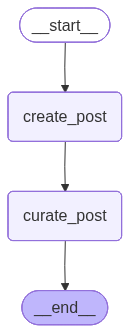

In [20]:
from IPython.display import Image, display

Image(message_graph.get_graph().draw_mermaid_png())

In [21]:
message_graph.invoke({
    "messages_manual": [HumanMessage(content="The importance of agentic AI in digital age")],
    "messages_auto": [HumanMessage(content="The importance of agentic AI in digital age")]
})

{'messages_manual': [HumanMessage(content='The importance of agentic AI in digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Agentic AI—systems that can **plan, take actions, use tools, and pursue goals over time**—is becoming central to the digital age because it shifts AI from “chatting” to **doing**. Here are the main reasons it’s important:\n\n### 1) Automates complex, multi-step work\nMany digital tasks aren’t single actions; they’re workflows (e.g., gather info → analyze → draft → verify → submit). Agentic AI can:\n- break goals into steps  \n- execute them with tools (browsers, databases, APIs)  \n- handle retries and intermediate decisions  \nThis reduces manual effort and cycle time.\n\n### 2) Makes AI more useful beyond knowledge Q&A\nTraditional AI often answers questions. Agentic AI can **operate on your behalf**, such as:\n- booking travel, scheduling, and coordinating  \n- processing tickets, generating reports, and updating systems  \n- moni